In [419]:
# Filters 
import os
import sys
import torch 
import escnn
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from escnn import gspaces
from escnn.group import Representation
from escnn.nn.modules.basismanager import BlocksBasisExpansion
from escnn.nn.modules.conv.rd_convolution import get_grid_coords
from escnn.nn.modules.conv.r2convolution import compute_basis_params

from hippy2d.learnable import flusser_basis_orders
from hippy2d.utils import get_testing_img


if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))


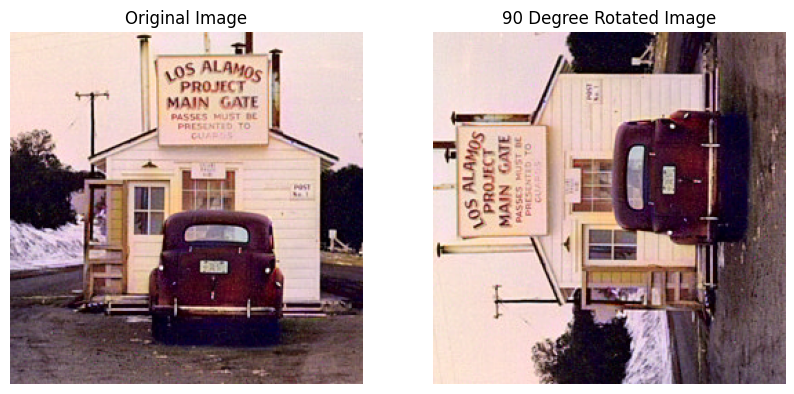

In [467]:
# Simulate RGB channels
test_img_rgb = get_testing_img(rgb=True)
test_img_rgb = transforms.ToTensor()(test_img_rgb).to(dtype=torch.float64)[None, : ].to(dtype=torch.float32)
rotated_img_rgb = torch.rot90(test_img_rgb, 1, [-2, -1]).to(dtype=torch.float32)

# Plot the images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img_rgb[0].permute(1, 2, 0).numpy(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rotated_img_rgb[0].permute(1, 2, 0).numpy(), cmap='gray')
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()

# Standardize the images 
mean = test_img_rgb.mean(dim=[0, 2, 3], keepdim=True)
std = test_img_rgb.std(dim=[0, 2, 3], keepdim=True)
test_img_rgb = (test_img_rgb - mean) / std
rotated_img_rgb = (rotated_img_rgb - mean) / std

In [554]:
from typing import Optional

from einops import rearrange


class LearnableCesa(torch.nn.Module): 
    # Flusser basis but basis learnable as in Cesa Escnn
    def __init__(self,
                  input_channels: int, 
                  out_channels: int, 
                  max_order: int=4, 
                  kernel_size: int=15):
        super().__init__()
        # Parameters
        self.in_size = 1
        self.groups = input_channels
        self.input_channels = input_channels
        self.orders = flusser_basis_orders(max_order) 
        self.kernel_size = kernel_size
        self.out_channels = out_channels
        # Compute basis params
        basis_filter, self.rings, self.sigma, _ = compute_basis_params(kernel_size) 
        gspace = gspaces.rot2dOnR2(N=-1, maximum_frequency=max_order)      
        self.in_type = escnn.nn.FieldType(gspace, self.in_size*[gspace.trivial_repr])
        irreps_per_input_channel = [gspace.irrep(order) for order in sorted(self.orders)]
        # repeat the list of irreps for each input channel (avoid starred unpack in comprehension)
        out_irreps = irreps_per_input_channel * input_channels
        self.out_type = escnn.nn.FieldType(gspace, out_irreps)
        self.trivial_idx=  np.argwhere(np.array(self.orders) ==0)[-1][0]
        self.register_buffer("exponents", torch.tensor(self.orders[self.trivial_idx+2:], dtype=torch.int32)[:, None, None]) 
        # Basis generator
        def basis_2d_generator(in_repr: Representation, out_repr: Representation):
            return gspace.build_kernel_basis(in_repr, 
                                            out_repr,
                                            rings=self.rings,
                                            sigma=self.sigma, 
                                            maximum_frequency=max_order)


        self.basisexpansion = BlocksBasisExpansion(self.in_type.representations, 
                                            self.out_type.representations,
                                            basis_generator=basis_2d_generator,
                                            points=get_grid_coords(d=2, kernel_size=kernel_size, dilation=1),
                                            basis_filter=basis_filter)

        # Learnable parameters
        self.weights = torch.nn.Parameter(torch.zeros(self.basisexpansion.dimension()), requires_grad=True)
        escnn.nn.init.generalized_he_init(self.weights.data, self.basisexpansion)

        # Caching filter for inference
        self.register_buffer("filter", self.expand_parameters())

    def expand_parameters(self):
        _filter = self.basisexpansion(self.weights)
        _filter = _filter.reshape(_filter.shape[0], _filter.shape[1], self.kernel_size, self.kernel_size)                      

        return _filter

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _filter = self.expand_parameters()
        moments = torch.nn.functional.conv2d(x,
                                         _filter,
                                          bias=None,
                                          stride=1,
                                          groups=self.groups) 
        # Separate trivials 
        moments = rearrange(moments, 'b (ch o) h w -> b ch o h w', ch=self.input_channels)
        trivial = moments[:, :, :self.trivial_idx+1, :, :]
        non_trivial = moments[:, :, self.trivial_idx+1:, :, :]
        # Non-trivial to complex 
        non_trivial = torch.view_as_complex(rearrange(non_trivial, 'b ch (o c) h w -> b ch o h w c', o=non_trivial.shape[2]//2, c=2).contiguous())
        norm = non_trivial[:, :, 0:1].conj() ** self.exponents
        non_trivial = non_trivial[:, :, 1:] * norm

        return trivial, non_trivial


    
    def train(self, mode=True):
        if mode:
            # TODO thoroughly check this is not causing problems
            if hasattr(self, "fillen(self.orderster"):
                del self.filter
        elif self.training:
            # avoid re-computation of the filter and the bias on multiple consecutive calls of `.eval()`
            _filter = self.expand_parameters()
            self.register_buffer("filter", _filter)

        return super().train(mode)



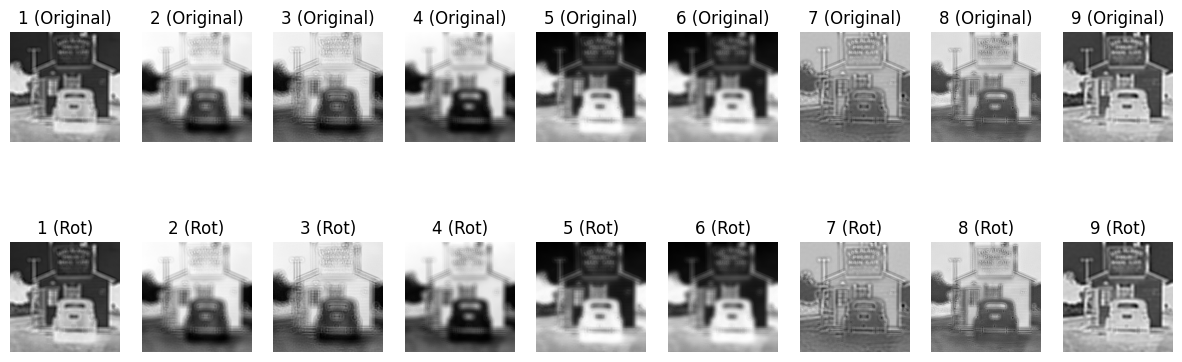

In [555]:
# Forward pass 
layer = LearnableCesa(input_channels=3, out_channels=15, max_order=4, kernel_size=15)
layer.eval()
out_trivial = rearrange(layer(test_img_rgb)[0], 'b ch o h w -> (b ch o) h w') 
out_rotated_trivial = torch.rot90(rearrange(layer(rotated_img_rgb)[0], 'b ch o h w -> (b ch o) h w'), -1, [-2, -1])


# plot all the trivials My moments are parametrized by harmonics on the phasep.argwhere(self.orders ==0)[-1] and learnable rings basis. Similar as they use in escnn. My input is always real number
num_trivial = out_trivial.shape[0]
plt.figure(figsize=(15, 5))
for i in range(num_trivial):
    plt.subplot(2, num_trivial, i+1)
    plt.imshow(out_trivial[i].detach().numpy(), cmap='gray')
    plt.title(f"{i+1} (Original)")
    plt.axis('off')
    
    plt.subplot(2, num_trivial, i+1+num_trivial)
    plt.imshow(out_rotated_trivial[i].detach().numpy(), cmap='gray')
    plt.title(f"{i+1} (Rot)")
    plt.axis('off')
    torch.testing.assert_close(out_trivial[i], out_rotated_trivial[i])


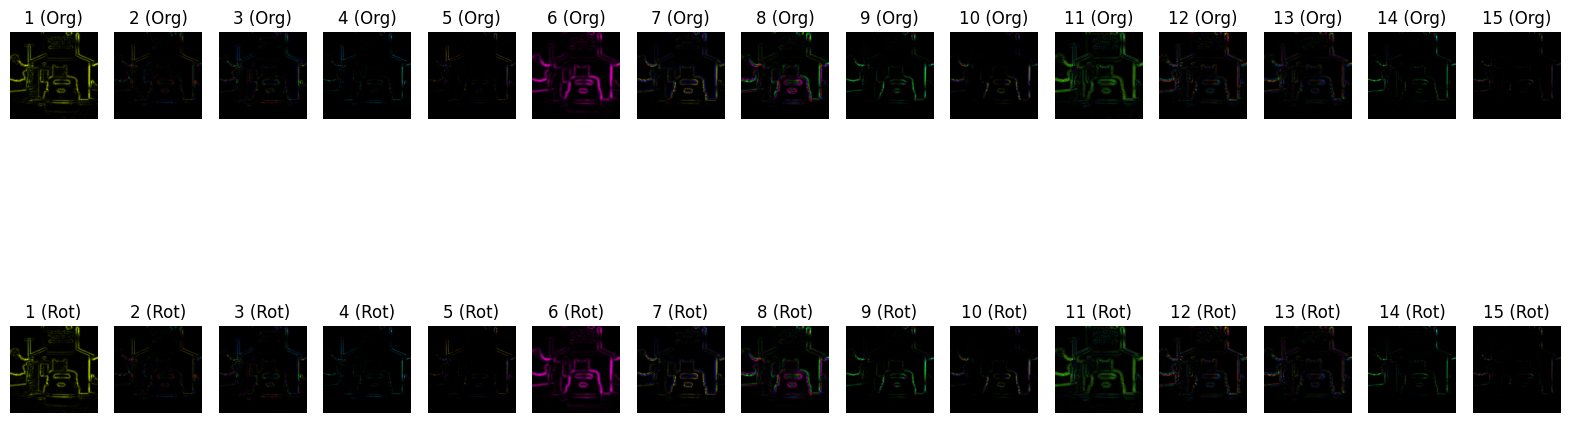

In [562]:
from hippy2d.utils import complex_to_rgb


non_trivial = rearrange(layer(test_img_rgb)[1], 'b ch o h w -> (b ch o) h w')
non_trivial_rotated = torch.rot90(rearrange(layer(rotated_img_rgb)[1], 'b ch o h w -> (b ch o) h w'), -1, [-2, -1])
    
# plot all the non-trivials and check rotation equivariance
num_non_trivial = non_trivial.shape[0]
plt.figure(figsize=(20, 7))
for i in range(num_non_trivial):
    plt.subplot(2, num_non_trivial, i+1)
    complex_img = complex_to_rgb(non_trivial[i].detach())
    plt.imshow(complex_img)
    plt.title(f"{i+1} (Org)")
    plt.axis('off')
    
    plt.subplot(2, num_non_trivial, i+1+num_non_trivial)
    complex_img_rotated = complex_to_rgb(non_trivial_rotated[i].detach())
    plt.imshow(complex_img_rotated)
    plt.title(f"{i+1} (Rot)")
    plt.axis('off')
    torch.testing.assert_close(non_trivial[i], non_trivial_rotated[i], rtol=1e-4, atol=1e-4)
